In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt



### DATA UPLOADING

In [4]:
df = pd.read_csv("/content/UberDataset.csv")

## **DATA ANALYSIS **

In [5]:
df.head(50)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
5,01-06-2016 17:15,01-06-2016 17:19,Business,West Palm Beach,West Palm Beach,4.3,Meal/Entertain
6,01-06-2016 17:30,01-06-2016 17:35,Business,West Palm Beach,Palm Beach,7.1,Meeting
7,01-07-2016 13:27,01-07-2016 13:33,Business,Cary,Cary,0.8,Meeting
8,01-10-2016 08:05,01-10-2016 08:25,Business,Cary,Morrisville,8.3,Meeting
9,01-10-2016 12:17,01-10-2016 12:44,Business,Jamaica,New York,16.5,Customer Visit


In [6]:
df["CATEGORY"].unique()

array(['Business', 'Personal', nan], dtype=object)

In [7]:
df.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [9]:
df.describe()


,MILES
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


In [10]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='object')

In [11]:
df.shape

(1156, 7)

In [12]:

df.isnull().sum()

,0
START_DATE,0
END_DATE,1
CATEGORY,1
START,1
STOP,1
MILES,0
PURPOSE,503


In [13]:
df['PURPOSE'] = df['PURPOSE'].fillna('Unknown')
df.dropna(inplace = True)


In [14]:
df.shape

(1155, 7)

In [15]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1150,False
1151,False
1152,False
1153,False


In [16]:
df.duplicated().sum()

np.int64(1)

In [17]:

df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

## FEATURE **ENGINEERING**

In [18]:
df['PURPOSE'].value_counts()

,count
PURPOSE,
Unknown,502
Meeting,186
Meal/Entertain,160
Errand/Supplies,128
Customer Visit,101
Temporary Site,50
Between Offices,18
Moving,4
Airport/Travel,3


In [19]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,Unknown
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,12/31/2016 1:07,12/31/2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site


In [20]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], format = 'mixed')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], format = 'mixed')


In [21]:
print(df['START_DATE'].dtype)

datetime64[ns]


In [22]:
df.rename(columns = {
          'START_DATE' : 'start_date',
          'eEND_DATE': 'end_date',
          'CATEGORY' : 'category',
          'START': 'start',
          'STOP': 'stop',
          'MILES' : 'miles',

          'PURPOSE' : 'purpose'})


,start_date,END_DATE,category,start,stop,miles,purpose
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site


In [23]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE'],
      dtype='object')

In [24]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site


In [25]:
df['day_name'] = df['START_DATE'].dt.day_name()
df['month_name'] = df['START_DATE'].dt.month_name()


In [26]:
time_periods = [ 0,6,12,18,24]
labels = [ 'Morining', 'Afternoon' , 'Evening', 'Night']
df['time_label'] = pd.cut(df['START_DATE'].dt.hour, bins = time_periods, labels = labels, right = False)

In [27]:
df['duration'] = df['END_DATE'] - df['START_DATE']

In [28]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,day_name,month_name,time_label,duration
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Friday,January,Night,0 days 00:06:00
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,Saturday,January,Morining,0 days 00:12:00
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Saturday,January,Night,0 days 00:13:00
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tuesday,January,Evening,0 days 00:14:00
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wednesday,January,Evening,0 days 01:07:00
...,...,...,...,...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,Saturday,December,Morining,0 days 00:07:00
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,Saturday,December,Evening,0 days 00:18:00
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,Saturday,December,Evening,0 days 00:35:00
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,Saturday,December,Night,0 days 00:18:00


In [29]:
df['month'] = df['START_DATE'].dt.month_name()

In [30]:
df['duration'] = (df['END_DATE']- df['START_DATE']).dt.total_seconds() / 60

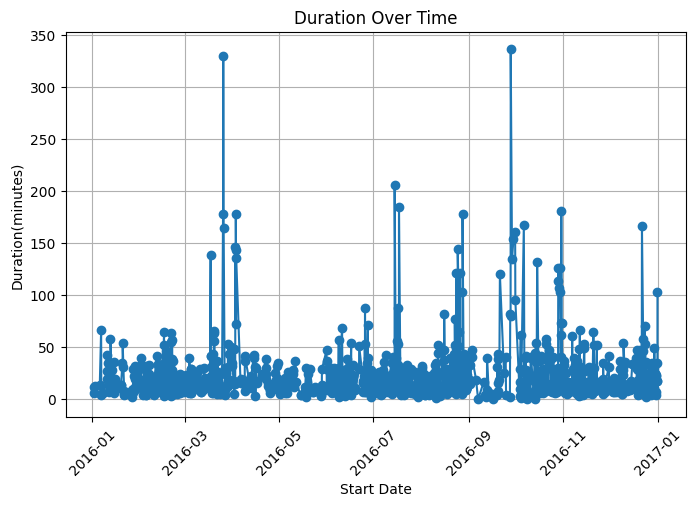

In [31]:
plt.figure(figsize = (8,5))
plt.plot(df['START_DATE'], df['duration'], marker = 'o')
plt.title('Duration Over Time')
plt.xlabel('Start Date')
plt.ylabel('Duration(minutes)')
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

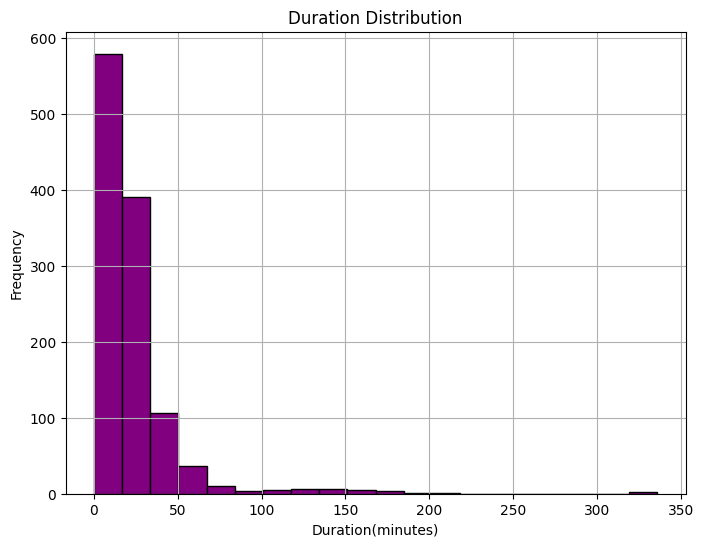

In [32]:
plt.figure(figsize = (8,6))
plt.hist(df['duration'], bins = 20 , color = 'purple', edgecolor = 'black')
plt.title('Duration Distribution')
plt.xlabel('Duration(minutes)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [33]:
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,day_name,month_name,time_label,duration,month
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Friday,January,Night,6.0,January
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,Saturday,January,Morining,12.0,January
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Saturday,January,Night,13.0,January
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tuesday,January,Evening,14.0,January
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wednesday,January,Evening,67.0,January
...,...,...,...,...,...,...,...,...,...,...,...,...
1150,2016-12-31 01:07:00,2016-12-31 01:14:00,Business,Kar?chi,Kar?chi,0.7,Meeting,Saturday,December,Morining,7.0,December
1151,2016-12-31 13:24:00,2016-12-31 13:42:00,Business,Kar?chi,Unknown Location,3.9,Temporary Site,Saturday,December,Evening,18.0,December
1152,2016-12-31 15:03:00,2016-12-31 15:38:00,Business,Unknown Location,Unknown Location,16.2,Meeting,Saturday,December,Evening,35.0,December
1153,2016-12-31 21:32:00,2016-12-31 21:50:00,Business,Katunayake,Gampaha,6.4,Temporary Site,Saturday,December,Night,18.0,December


In [34]:
import seaborn as sns

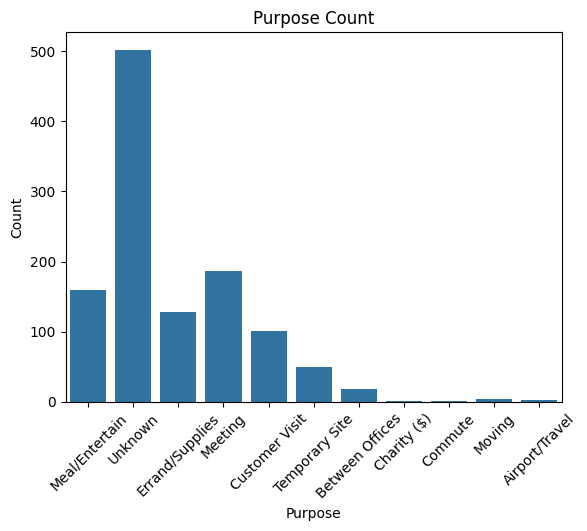

In [35]:
sns.countplot(x = df['PURPOSE'])
plt.title('Purpose Count')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

In [36]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'day_name', 'month_name', 'time_label', 'duration', 'month'],
      dtype='object')

/tmp/ipykernel_2471/179460526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = ride_purpose_counts, y = ride_purpose_counts.index, palette = 'viridis')


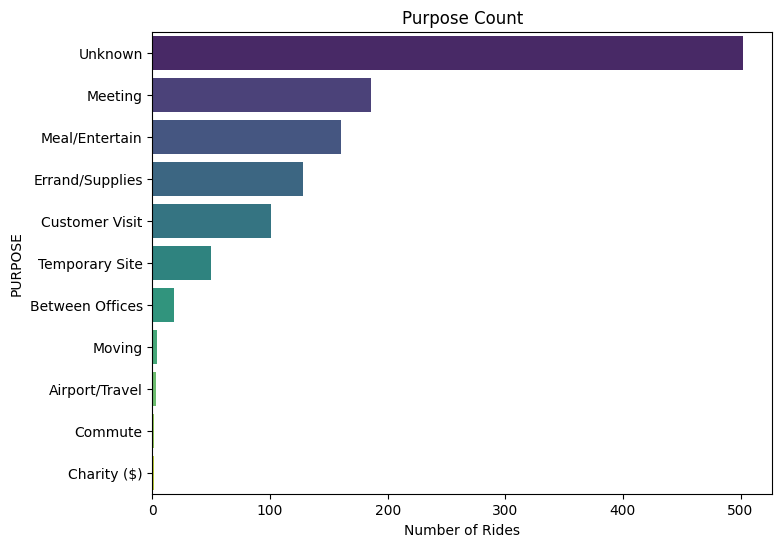

In [37]:
ride_purpose_counts = df['PURPOSE'].value_counts()

plt.figure(figsize = (8,6))
sns.barplot(x = ride_purpose_counts, y = ride_purpose_counts.index, palette = 'viridis')
plt.title('Purpose Count')
plt.xlabel('Number of Rides')
plt.ylabel('PURPOSE')
plt.show()

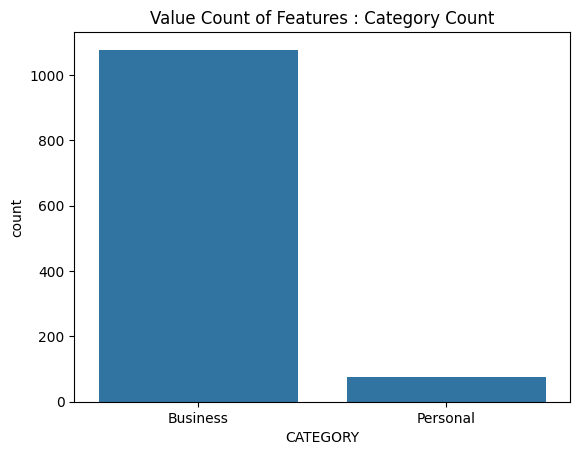

In [38]:
sns.countplot(x = df['CATEGORY'])
plt.title('Value Count of Features : Category Count')
plt.show()

/tmp/ipykernel_2471/1378397150.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['day_name'],  palette = 'Set1', legend = False )


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Friday'),
  Text(1, 0, 'Saturday'),
  Text(2, 0, 'Tuesday'),
  Text(3, 0, 'Wednesday'),
  Text(4, 0, 'Thursday'),
  Text(5, 0, 'Sunday'),
  Text(6, 0, 'Monday')])

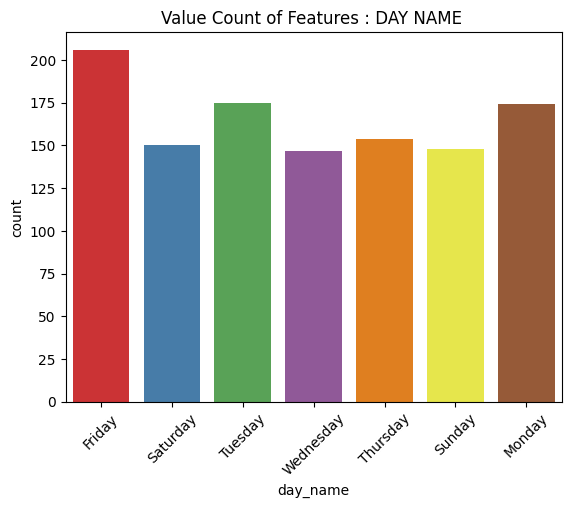

In [39]:

sns.countplot(x = df['day_name'],  palette = 'Set1', legend = False )
plt.title('Value Count of Features : DAY NAME ')
plt.xticks(rotation = 45 )


/tmp/ipykernel_2471/2966052348.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['month'], palette = 'Set2', legend = False)


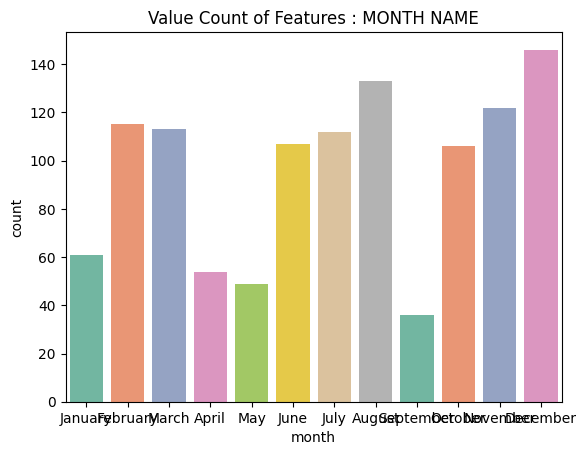

In [40]:

sns.countplot(x = df['month'], palette = 'Set2', legend = False)
plt.title('Value Count of Features : MONTH NAME')
plt.show()

/tmp/ipykernel_2471/2119412790.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['time_label'], palette = 'Set3', legend = False)


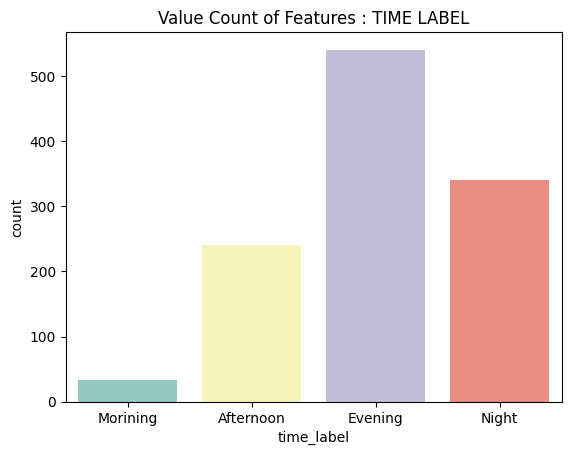

In [41]:
sns.countplot(x = df['time_label'], palette = 'Set3', legend = False)
plt.title('Value Count of Features : TIME LABEL')
plt.show()

In [42]:
df.columns


Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'day_name', 'month_name', 'time_label', 'duration', 'month'],
      dtype='object')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Meal/Entertain'),
  Text(1, 0, 'Unknown'),
  Text(2, 0, 'Errand/Supplies'),
  Text(3, 0, 'Meeting'),
  Text(4, 0, 'Customer Visit'),
  Text(5, 0, 'Temporary Site'),
  Text(6, 0, 'Between Offices'),
  Text(7, 0, 'Charity ($)'),
  Text(8, 0, 'Commute'),
  Text(9, 0, 'Moving'),
  Text(10, 0, 'Airport/Travel')])

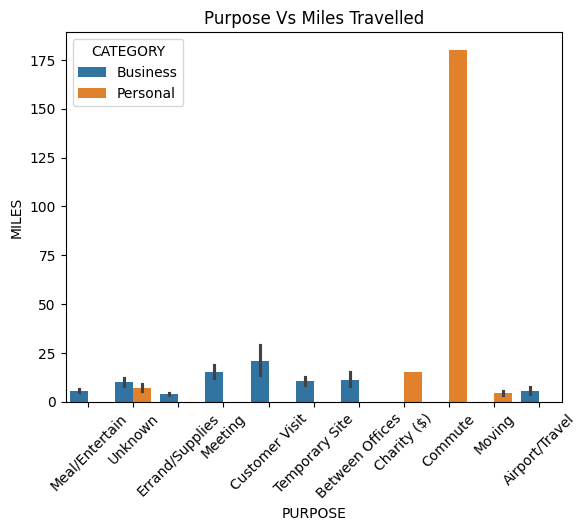

In [43]:
sns.barplot(x = df['PURPOSE'], y = df['MILES'] , hue = df['CATEGORY'])
plt.title('Purpose Vs Miles Travelled')
plt.xticks(rotation = 45)

([0, 1], [Text(0, 0, 'Business'), Text(1, 0, 'Personal')])

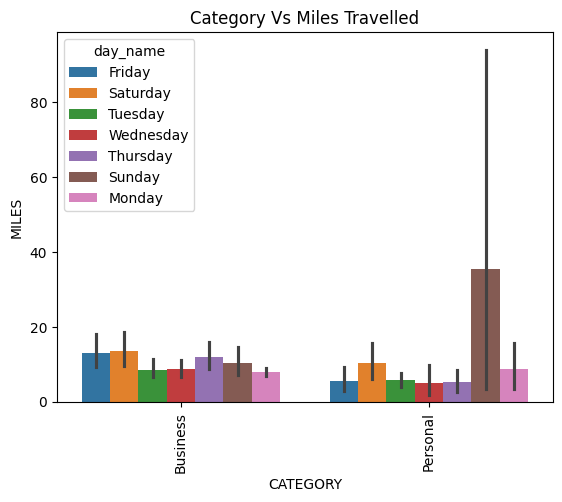

In [44]:
sns.barplot( x = df['CATEGORY'], y = df['MILES'], hue = df['day_name'])
plt.title('Category Vs Miles Travelled')
plt.xticks(rotation = 90)


([0, 1, 2, 3],
 [Text(0, 0, 'Morining'),
  Text(1, 0, 'Afternoon'),
  Text(2, 0, 'Evening'),
  Text(3, 0, 'Night')])

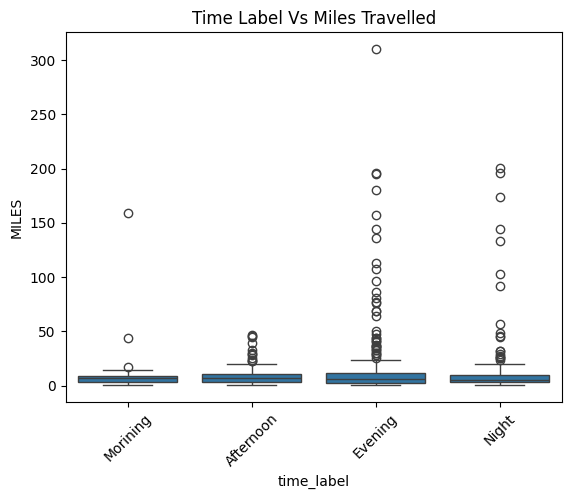

In [45]:
sns.boxplot(x = df['time_label'], y = df['MILES'])
plt.title('Time Label Vs Miles Travelled')
plt.xticks(rotation = 45)

Text(0.5, 1.0, 'Outliers in Duration')

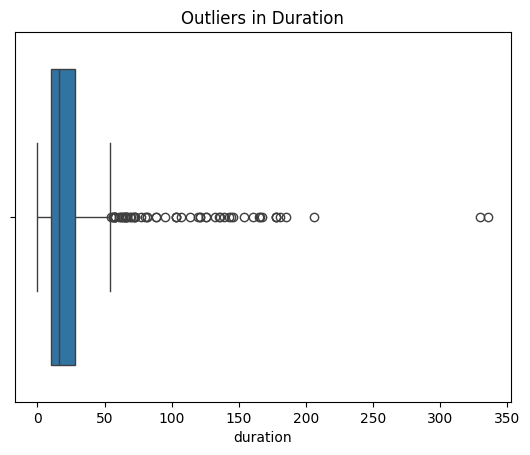

In [46]:
sns.boxplot(x = df['duration'], data = df)
plt.title('Outliers in Duration')


/tmp/ipykernel_2471/3115555467.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['MILES'])


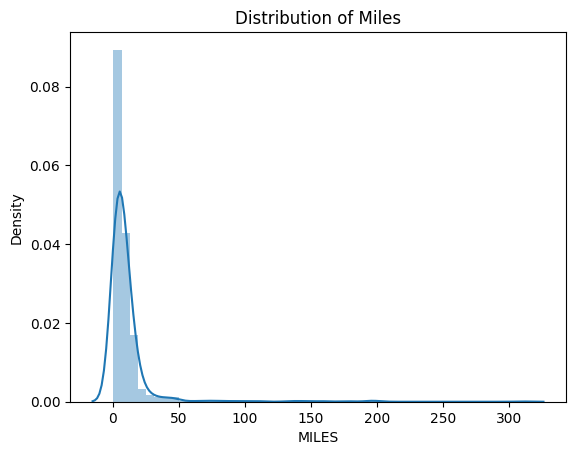

In [47]:
sns.distplot(df['MILES'])
plt.title('Distribution of Miles')
plt.show()

PROBABILITY DENSITY FUNCTION


/tmp/ipykernel_2471/4288384445.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['MILES'], hist = False, label = 'MILES')
/tmp/ipykernel_2471/4288384445.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['duration'], hist = False , label = 'Duration')


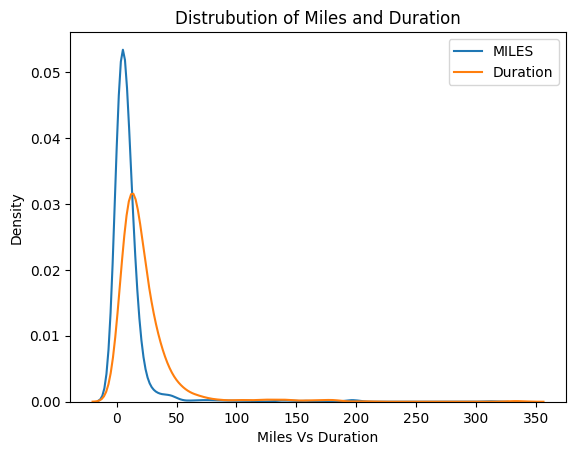

In [48]:
sns.distplot(df['MILES'], hist = False, label = 'MILES')
sns.distplot(df['duration'], hist = False , label = 'Duration')
plt.title('Distrubution of Miles and Duration')
plt.xlabel('Miles Vs Duration')
plt.legend()
plt.show()

In [49]:
df.to_csv('uber_final.csv', index=False)

In [50]:
!pip install Colorama


In [51]:
from colorama import Fore , Style ,init
init()

In [52]:
df.columns

Index(['START_DATE', 'END_DATE', 'CATEGORY', 'START', 'STOP', 'MILES',
       'PURPOSE', 'day_name', 'month_name', 'time_label', 'duration', 'month'],
      dtype='object')

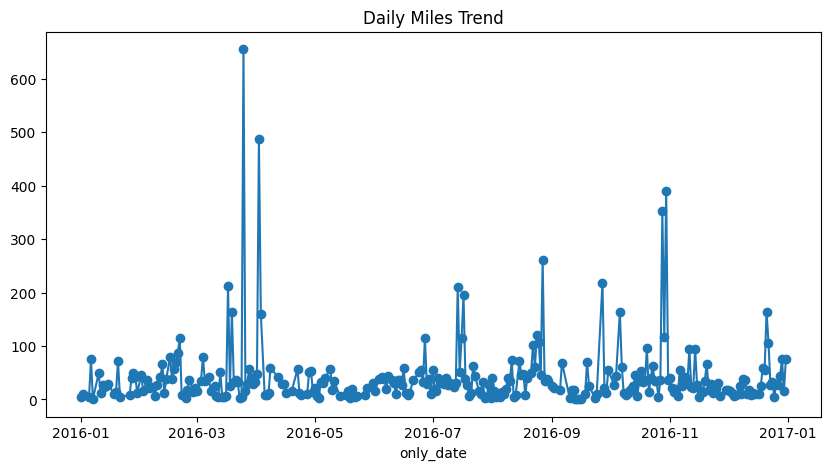

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

df.columns = df.columns.str.lower()

df = df[df['start_date'].astype(str).str.contains('Total') == False]
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df = df.dropna(subset=['start_date'])

# 3. Daily Analysis
df['only_date'] = df['start_date'].dt.date
daily_miles = df.groupby('only_date')['miles'].sum()

# 4. Plotting
plt.figure(figsize=(10, 5))
daily_miles.plot(kind='line', marker='o')
plt.title('Daily Miles Trend')
plt.show()

In [54]:
df.head()

,start_date,end_date,category,start,stop,miles,purpose,day_name,month_name,time_label,duration,month,only_date
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,Friday,January,Night,6.0,January,2016-01-01
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,Saturday,January,Morining,12.0,January,2016-01-02
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,Saturday,January,Night,13.0,January,2016-01-02
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,Tuesday,January,Evening,14.0,January,2016-01-05
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,Wednesday,January,Evening,67.0,January,2016-01-06


In [55]:
df.columns

Index(['start_date', 'end_date', 'category', 'start', 'stop', 'miles',
       'purpose', 'day_name', 'month_name', 'time_label', 'duration', 'month',
       'only_date'],
      dtype='object')

In [56]:
# using pandas to encoding feature
#data = df
df_encoded = pd.get_dummies(df, columns = [ 'category', 'start', 'purpose', 'stop', 'day_name', 'time_label', 'month'])


In [57]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
X = df_encoded.drop(['miles', 'start_date', 'end_date'], axis = 1)
y = df_encoded['miles']
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42)

In [58]:
from sklearn.metrics import mean_squared_error ,  r2_score , mean_absolute_error


In [60]:
print(X.dtypes)

month_name            object
duration             float64
only_date             object
category_Business       bool
category_Personal       bool
                      ...   
month_March             bool
month_May               bool
month_November          bool
month_October           bool
month_September         bool
Length: 404, dtype: object


In [65]:
X = X.drop(['month_name', 'only_date'], axis=1, errors='ignore')

In [67]:
print("Bache huye string columns:", X.select_dtypes(include=['object']).columns.tolist())

Bache huye string columns: []


In [68]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['month'] = df['month'].map(month_map)

In [69]:
X = X.drop(['month_name', 'only_date'], axis=1, errors='ignore')

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor , AdaBoostRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)
import xgboost as xgb
!pip install catboost
from catboost import CatBoostRegressor
import lightgbm as lgb




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00


In [75]:
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree' : DecisionTreeRegressor(),
    'Random Forest' : RandomForestRegressor(),
    'SVR' : SVR(),
    'KNeighbours'   : KNeighborsRegressor(),
    'Linear SVR' : LinearSVR(),
    'XGBoost' : xgb.XGBRegressor(),
    'CatBoost' : CatBoostRegressor(),
    'LightGBM' : lgb.LGBMRegressor(),
    'GradientBosting' : GradientBoostingRegressor(),
    'AdaBoost' : AdaBoostRegressor()
}

In [76]:
print(y.head())

0     5.1
1     5.0
2     4.8
3     4.7
4    63.7
Name: miles, dtype: float64


In [77]:
print(X.dtypes)

duration             float64
category_Business       bool
category_Personal       bool
start_Agnew             bool
start_Almond            bool
                      ...   
month_March             bool
month_May               bool
month_November          bool
month_October           bool
month_September         bool
Length: 402, dtype: object


In [78]:
X = X.drop(['month_name', 'only_date'], axis=1, errors='ignore')

In [79]:
print(X.dtypes)

duration             float64
category_Business       bool
category_Personal       bool
start_Agnew             bool
start_Almond            bool
                      ...   
month_March             bool
month_May               bool
month_November          bool
month_October           bool
month_September         bool
Length: 402, dtype: object


In [80]:
print("Bache huye string columns:", X.select_dtypes(include=['object']).columns.tolist())

Bache huye string columns: []


In [81]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['month'] = df['month'].map(month_map)

In [82]:

X = X.drop(['month_name', 'only_date'], axis=1, errors='ignore')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

predictions = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training SVR...
Training KNeighbours...
Training Linear SVR...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training XGBoost...
Training CatBoost...
Learning rate set to 0.040428
0:	learn: 19.5762283	total: 48.2ms	remaining: 48.1s
1:	learn: 19.1419804	total: 51.3ms	remaining: 25.6s
2:	learn: 18.7730268	total: 54.4ms	remaining: 18.1s
3:	learn: 18.3759796	total: 57.1ms	remaining: 14.2s
4:	learn: 18.0149437	total: 59.6ms	remaining: 11.9s
5:	learn: 17.7386380	total: 61.5ms	remaining: 10.2s
6:	learn: 17.4423022	total: 64.7ms	remaining: 9.19s
7:	learn: 17.1504297	total: 67.5ms	remaining: 8.37s
8:	learn: 16.8265159	total: 70.8ms	remaining: 7.79s
9:	learn: 16.5145416	total: 72ms	remaining: 7.13s
10:	learn: 16.2539586	total: 74.7ms	remaining: 6.72s
11:	learn: 15.9482519	total: 77.3ms	remaining: 6.37s
12:	learn: 15.7262822	total: 79.7ms	remaining: 6.05s
13:	learn: 15.4435814	total: 82.7ms	remaining: 5.82s
14:	learn: 15.1612128	total: 84.9ms	remaining: 5.57s
15:	learn: 14.9394403	total: 87.7ms	remaining: 5.39s
16:	learn: 14.7025781	total: 90.5ms	remaining: 5.23s
17:	learn: 14.4414285	total: 93ms	remain

Results for Linear Regression:
Mean Squared Error: 309.3687393418529
R-squared Score: 0.5723452385787187


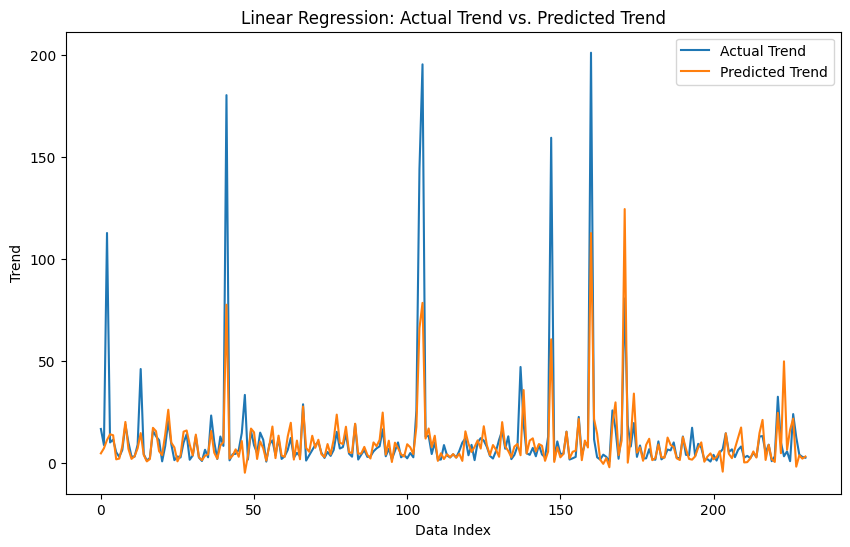


Results for Decision Tree:
Mean Squared Error: 155.70640692640697
R-squared Score: 0.7847598097741316


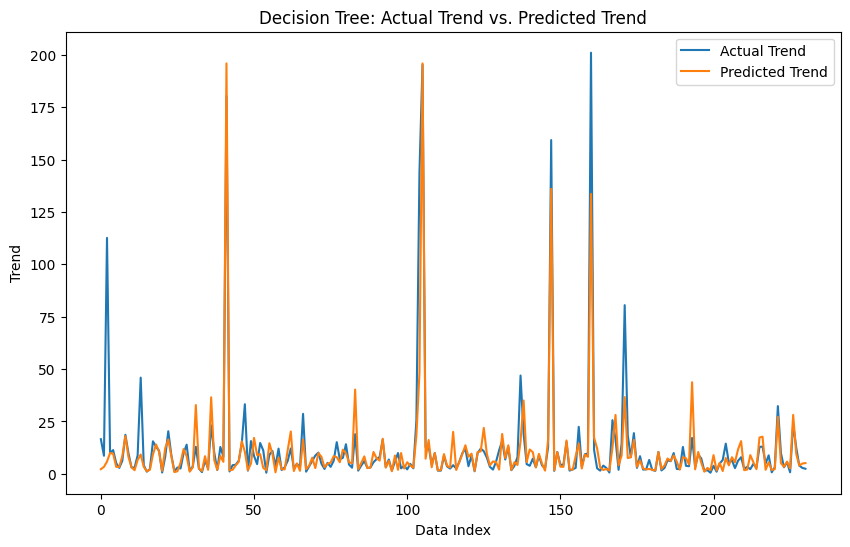


Results for Random Forest:
Mean Squared Error: 180.64122858549183
R-squared Score: 0.7502912489544976


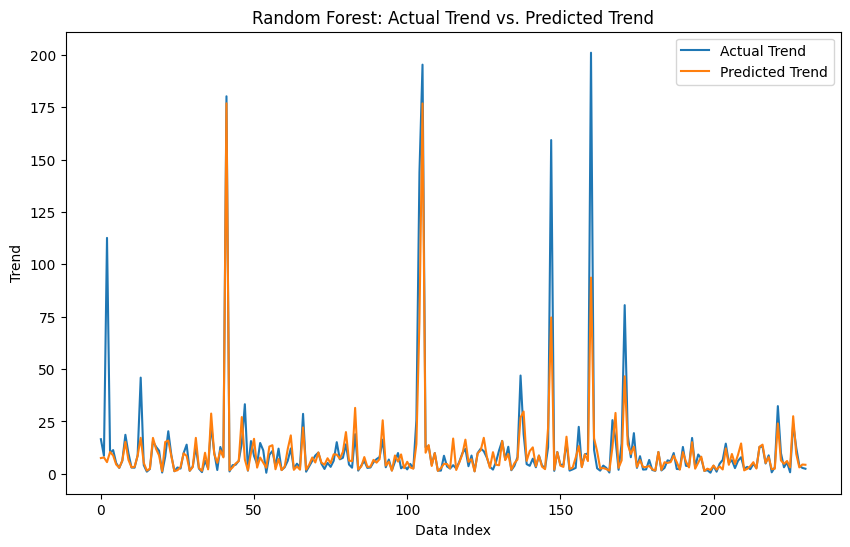


Results for SVR:
Mean Squared Error: 606.9156550605561
R-squared Score: 0.16103233242011794


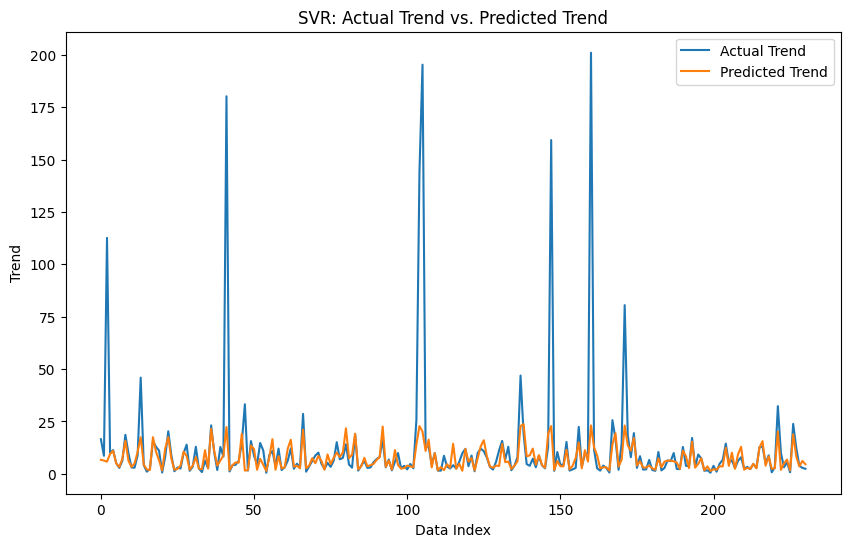


Results for KNeighbours:
Mean Squared Error: 240.24090389610387
R-squared Score: 0.6679038526714451


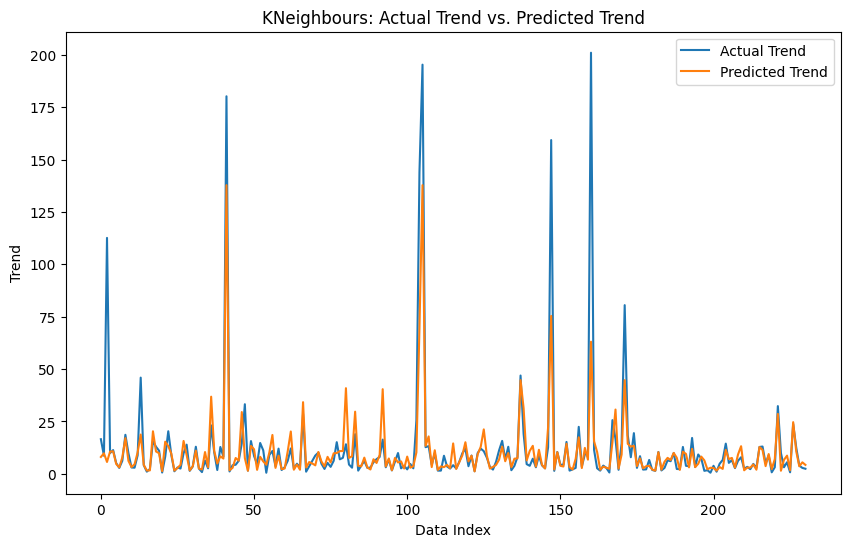


Results for Linear SVR:
Mean Squared Error: 346.9550895702488
R-squared Score: 0.5203878828555226


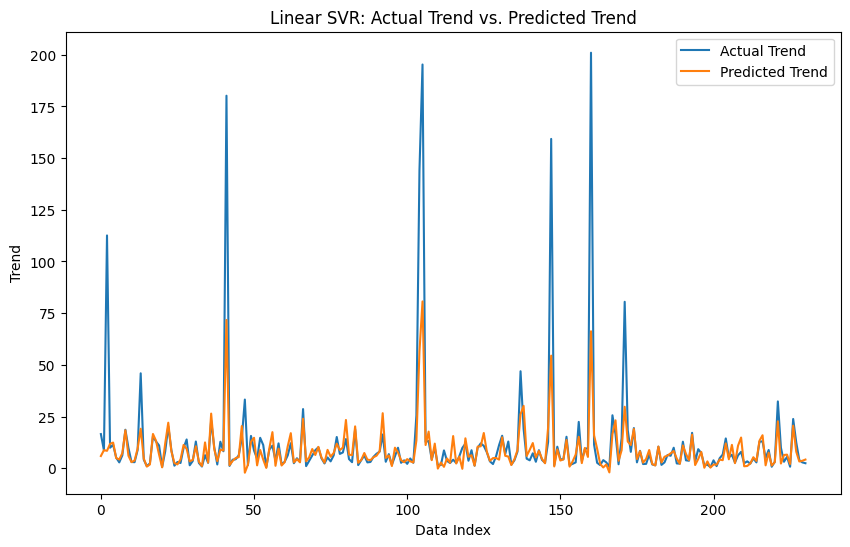


Results for XGBoost:
Mean Squared Error: 129.3486236917802
R-squared Score: 0.8211953963973248


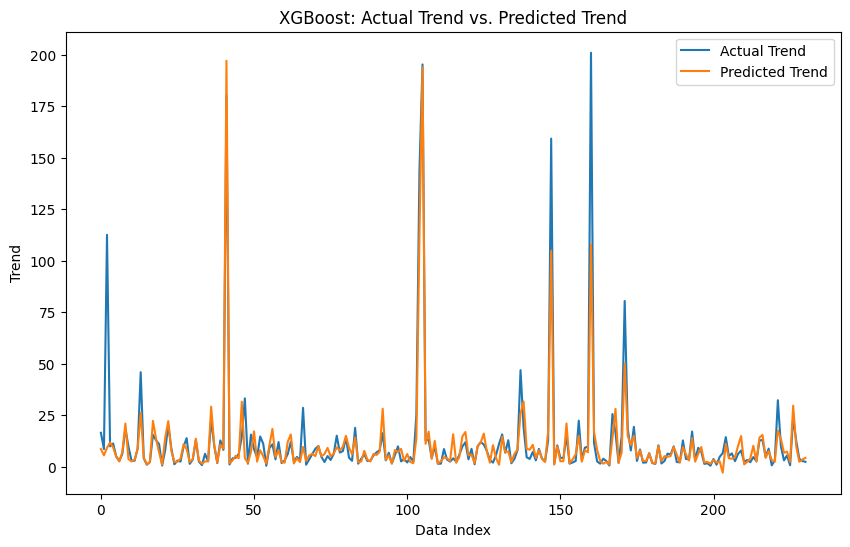


Results for CatBoost:
Mean Squared Error: 191.31441840668083
R-squared Score: 0.7355372034866363


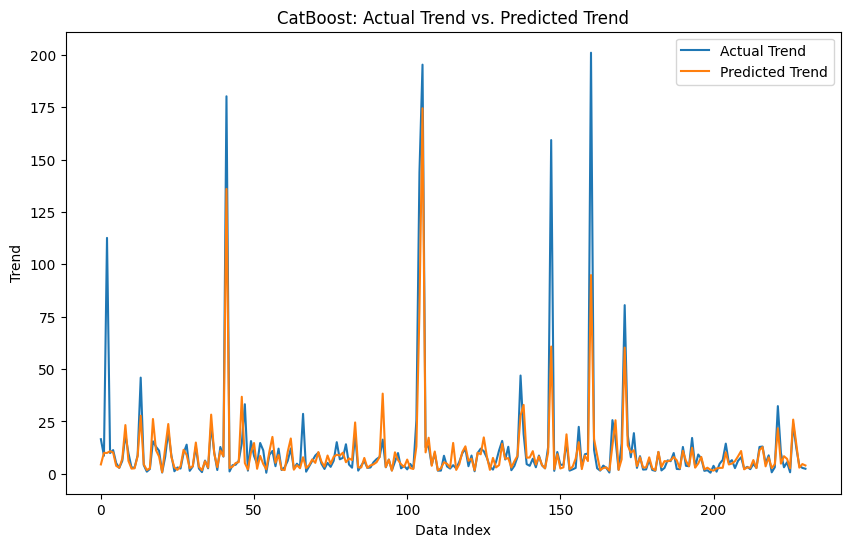


Results for LightGBM:
Mean Squared Error: 176.7523595912864
R-squared Score: 0.7556670129875851


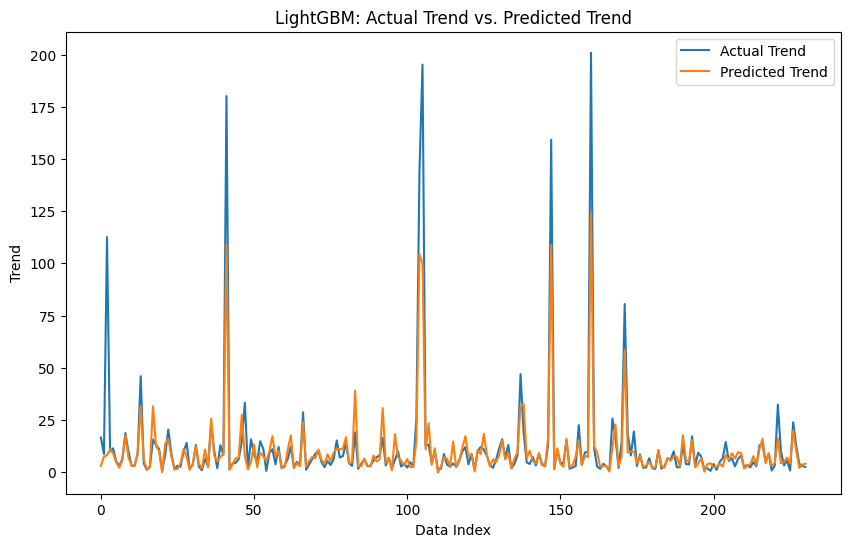


Results for GradientBosting:
Mean Squared Error: 194.30892030050805
R-squared Score: 0.731397764590177


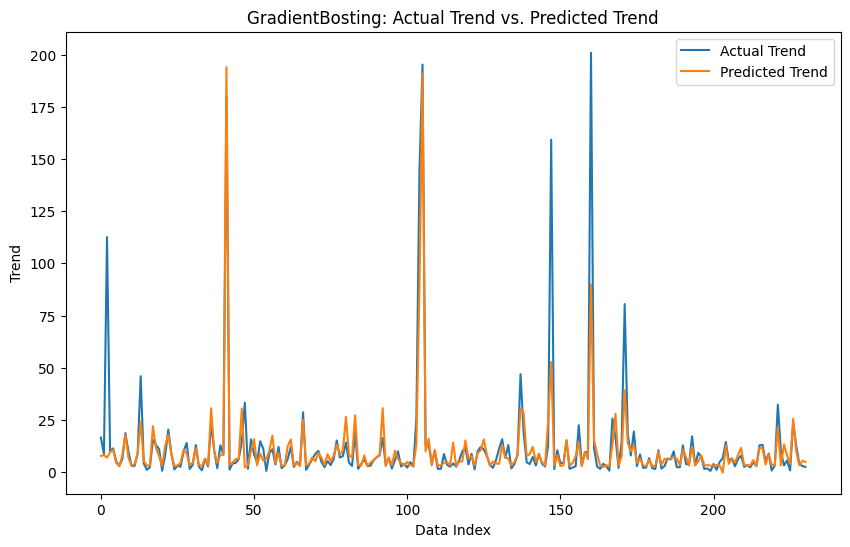


Results for AdaBoost:
Mean Squared Error: 186.2052275585626
R-squared Score: 0.7425998750346927


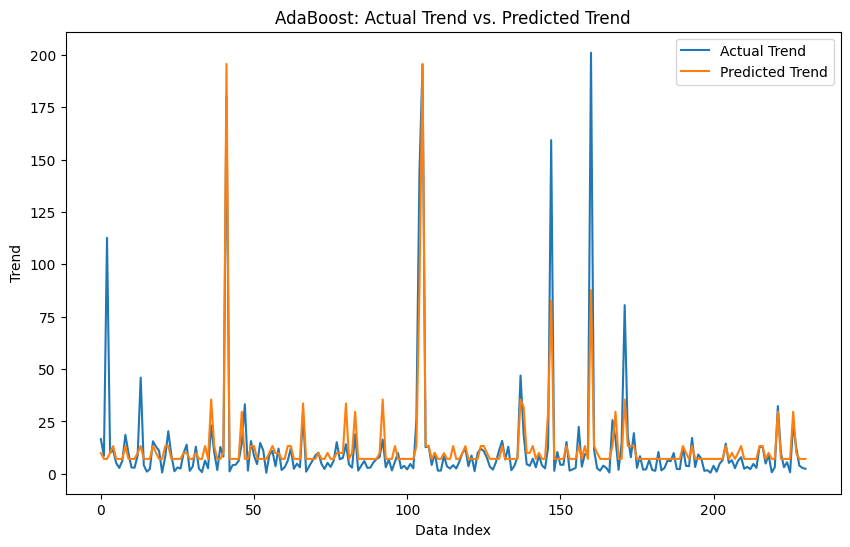

In [85]:
accuracy = {}

for name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    accuracy[name] = r2

    print(f"Results for {name}:")
    print(f"Mean Squared Error: {mse}")
    print(f"R-squared Score: {r2}")

    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(len(y_test)), y_test, label='Actual Trend')
    plt.plot(np.arange(len(y_test)), y_pred, label='Predicted Trend')
    plt.xlabel('Data Index')
    plt.ylabel('Trend')
    plt.title(f'{name}: Actual Trend vs. Predicted Trend')
    plt.legend()
    plt.show()
    print()

In [86]:
# Sahi tareeka:
import pandas as pd

# 'accuracy' dictionary se DataFrame banana
accuracy_df = pd.DataFrame({
    'Model Name': list(accuracy.keys()),
    'Accuracy Score': list(accuracy.values())
})

# Display the table
accuracy_df = accuracy_df.sort_values(by='Accuracy Score', ascending=False)
print(accuracy_df)


           Model Name  Accuracy Score
6             XGBoost        0.821195
1       Decision Tree        0.784760
8            LightGBM        0.755667
2       Random Forest        0.750291
10           AdaBoost        0.742600
7            CatBoost        0.735537
9     GradientBosting        0.731398
4         KNeighbours        0.667904
0   Linear Regression        0.572345
5          Linear SVR        0.520388
3                 SVR        0.161032


/tmp/ipykernel_2471/3677583973.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Accuracy Score', y='Model Name', data=accuracy_df, palette='viridis')


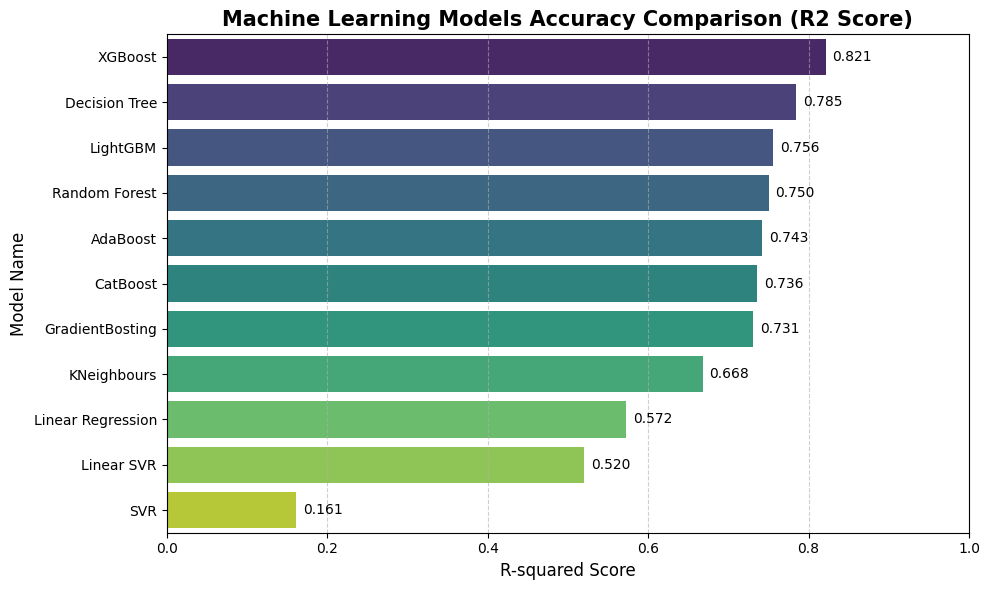

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting Size Set
plt.figure(figsize=(10, 6))

# Barplot banana (I Use Horizontal Bar Chart)
ax = sns.barplot(x='Accuracy Score', y='Model Name', data=accuracy_df, palette='viridis')

# Har bar ke aage uski value likhna (Annotation)
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')

# Labels aur Title
plt.title('Machine Learning Models Accuracy Comparison (R2 Score)', fontsize=15, fontweight='bold')
plt.xlabel('R-squared Score', fontsize=12)
plt.ylabel('Model Name', fontsize=12)
plt.xlim(0, 1) # Accuracy 0 se 1 ke beech dikhani hai
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [89]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.6.0.54.57
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.12.2
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
catboost==1.2.10
cert

In [90]:
import pickle

# Saving Winner Model
best_model = models['XGBoost']
pickle.dump(best_model, open('uber_model.pkl', 'wb'))

#Columns Model
model_columns = list(X.columns)
pickle.dump(model_columns, open('model_columns.pkl', 'wb'))